# 04 — Feature Engineering

Now that appliance switching events have been detected, we can extract features that summarize the characteristics of each event.

### Why Feature Engineering?

Event detection tells us when a power transition occurred.

Feature engineering converts each detected event into a numerical fingerprint that can later be used by a machine learning model to distinguish between appliances.

For example, a kettle, refrigerator, and microwave may all generate ON events, but they differ substantially in power level, duration, stability, and temporal usage patterns.

### Features we extract

- **delta_power** – magnitude of the detected power transition
- **steady_state_mean** – average power after the event
- **steady_state_std** – stability of the power level after switching
- **power_before_mean** – operating level before the event
- **rise_time_seconds** – transition speed (useful for motor vs resistive loads)
- **direction** – ON or OFF event
- **time_of_day_hour** – temporal usage pattern


### Label Assignment

Ground-truth appliance labels are obtained from the REFIT sub-meter measurements. For each detected aggregate event, the appliance exhibiting the largest simultaneous power change is assigned as the event label.

This converts the event detection problem into a supervised classification dataset that can later be used to train machine learning models.

## My Expectation

I expect steady-state power and delta_power to be among the most informative features because different appliances operate at distinct power levels. Duration- and timing-related features may provide additional separation when appliances have similar power consumption patterns.

In [6]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from utils.signal_utils import extract_event_features

plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
df = pd.read_csv('../data/processed/house1_7days.csv',
                 index_col=0,
                 parse_dates=True)

events = pd.read_csv('../data/processed/detected_events.csv',
                     parse_dates=['timestamp'])

appliance_map = {
    'Appliance1': 'Fridge',
    'Appliance2': 'Freezer',
    'Appliance3': 'Washer_Dryer',
    'Appliance4': 'Washing_Machine',
    'Appliance5': 'Toaster',
    'Appliance6': 'Computer',
    'Appliance7': 'Television',
    'Appliance8': 'Microwave'
}

df = df.rename(columns=appliance_map)

print(f'Events to process: {len(events)}')
print(f'Appliances available: {[c for c in df.columns if c != "mains"]}')

Events to process: 1681
Appliances available: ['Fridge', 'Freezer', 'Washer_Dryer', 'Washing_Machine', 'Toaster', 'Computer', 'Television', 'Microwave']


### Dataset Overview

The event detector identified 1,681 appliance switching events over the seven-day observation period. These events will be converted into numerical feature vectors and paired with appliance labels for supervised learning.

## Assign ground-truth labels

For each detected event, we need to know which appliance caused it.

Strategy: at each event timestamp, find the appliance with the largest absolute change in power.
This is a simple but effective label assignment — the appliance that changed the most is most likely the one that switched.

In [8]:
appliance_cols = [c for c in df.columns if c != 'mains']

def assign_label(timestamp, df, appliance_cols, window=5):
    '''
    Find which appliance had the largest power change around this timestamp.
    '''
    t_start = timestamp - pd.Timedelta(seconds=window)
    t_end   = timestamp + pd.Timedelta(seconds=window)
    window_df = df[appliance_cols][t_start:t_end]

    if len(window_df) < 2:
        return 'unknown'

    changes = window_df.diff().abs().max()
    best = changes.idxmax()

    # only assign label if the change is meaningful
    if changes[best] < 20:
        return 'unknown'
    return best

# test on first event
test_ts = events['timestamp'].iloc[0]
print('Label for first event:', assign_label(test_ts, df, appliance_cols))

Label for first event: Washer_Dryer


In [9]:
# assign labels to all events
print('Assigning labels...')
events['label'] = events['timestamp'].apply(
    lambda ts: assign_label(ts, df, appliance_cols)
)

print('\nLabel distribution:')
print(events['label'].value_counts())

Assigning labels...

Label distribution:
label
unknown         1433
Freezer           69
Washer_Dryer      62
Fridge            57
Computer          57
Television         3
Name: count, dtype: int64


## My Observation

A large number of detected events were labeled as unknown, indicating that appliance attribution is more difficult than event detection. Among the identified events, the freezer, washer dryer, fridge, and computer contributed the most labeled events.

## Extract features for each event

In [10]:
mains = df['mains']

feature_rows = []
for _, event in events.iterrows():
    feat = extract_event_features(mains, event['timestamp'],
                                   window_before=30, window_after=60)
    if feat is None:
        continue
    feat['direction'] = 1 if event['direction'] == 'ON' else 0
    feat['label'] = event['label']
    feature_rows.append(feat)

feature_df = pd.DataFrame(feature_rows)

# drop unknown labels
feature_df = feature_df[feature_df['label'] != 'unknown']

# drop appliances with very few events — not enough to train on
min_events = 10
counts = feature_df['label'].value_counts()
valid_labels = counts[counts >= min_events].index
feature_df = feature_df[feature_df['label'].isin(valid_labels)]

print(f'Feature matrix: {feature_df.shape}')
print('\nEvents per appliance:')
print(feature_df['label'].value_counts())

Feature matrix: (245, 13)

Events per appliance:
label
Freezer         69
Washer_Dryer    62
Fridge          57
Computer        57
Name: count, dtype: int64


## My Observation

After removing unknown events and appliance classes with very few samples, 245 labeled events remain. The freezer, washer dryer, fridge, and computer have a similar number of examples, resulting in a reasonably balanced dataset for model training.

## Feature distributions across appliances

To better understand the extracted features, we compare their distributions across different appliances.

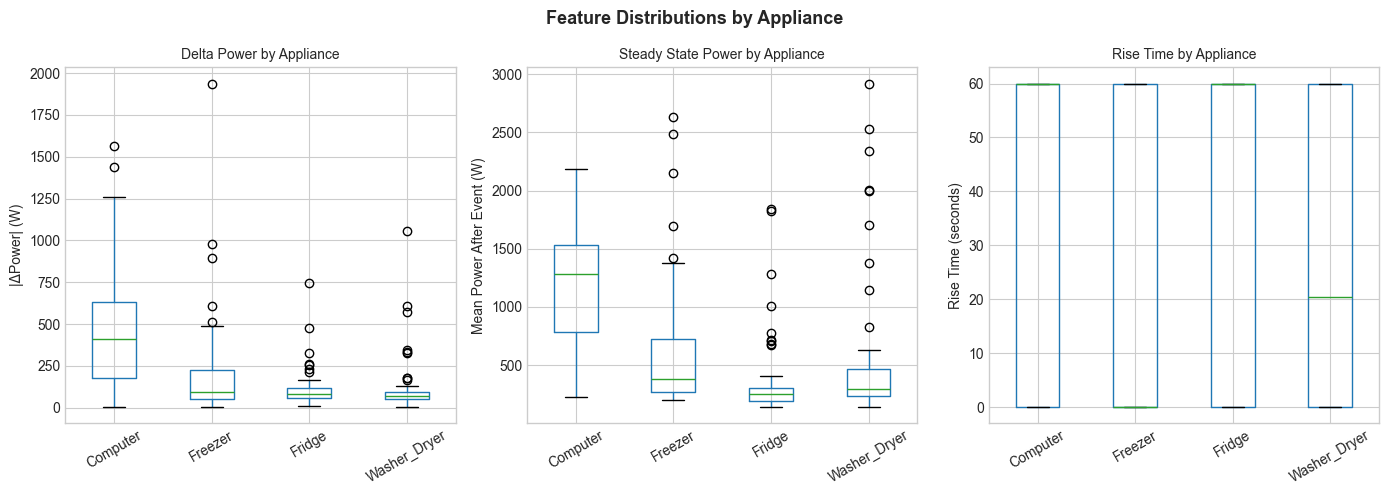

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. delta_power by appliance
feature_df.boxplot(column='delta_power_abs', by='label', ax=axes[0], rot=30)
axes[0].set_title('Delta Power by Appliance', fontsize=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('|ΔPower| (W)')

# 2. steady state mean by appliance
feature_df.boxplot(column='steady_state_mean', by='label', ax=axes[1], rot=30)
axes[1].set_title('Steady State Power by Appliance', fontsize=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Power After Event (W)')

# 3. rise time by appliance
feature_df.boxplot(column='rise_time_seconds', by='label', ax=axes[2], rot=30)
axes[2].set_title('Rise Time by Appliance', fontsize=10)
axes[2].set_xlabel('')
axes[2].set_ylabel('Rise Time (seconds)')

for ax in axes:
    ax.title.set_fontsize(10)
plt.suptitle('Feature Distributions by Appliance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_feature_distributions.png', dpi=150)
plt.show()

## My Observation

The feature distributions show noticeable differences across appliance classes. Computer events generally correspond to higher steady-state power levels, while fridge events tend to occur at lower levels. Differences in delta power are also visible between appliances, suggesting that these features contain useful information for classification.

Although there is some overlap between classes, the features provide enough separation to justify training a machine learning model in the next stage.

## Feature Correlation Analysis

To better understand the feature set, I examined the correlation between the extracted numerical features. Highly correlated features may provide similar information, while weakly correlated features can contribute additional discriminatory power for classification.

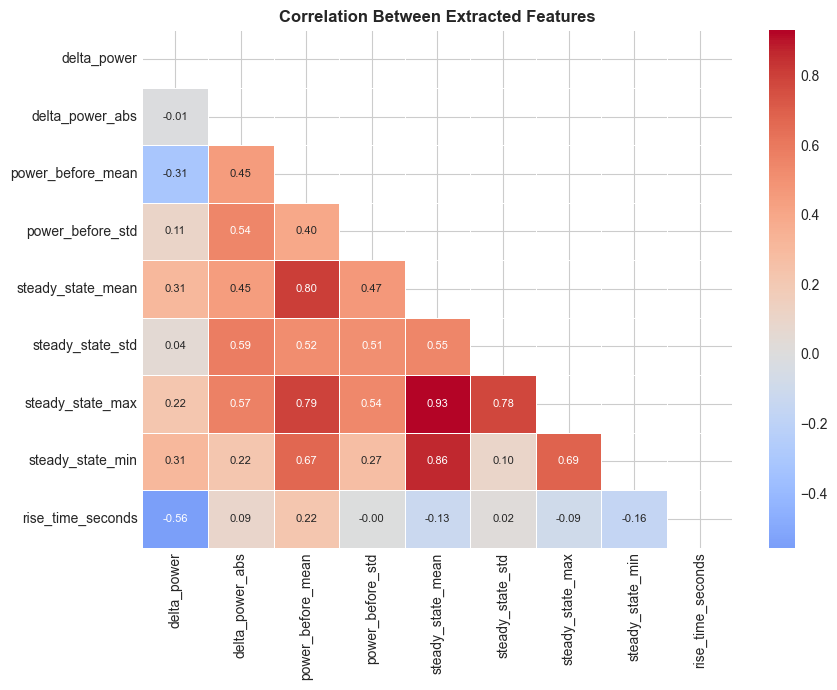

In [13]:
# correlation heatmap of features
numeric_features = feature_df.select_dtypes(include=np.number).drop(columns=['time_of_day_hour','is_nighttime','direction'], errors='ignore')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(numeric_features.corr(), dtype=bool))
sns.heatmap(numeric_features.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Between Extracted Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_feature_correlation.png', dpi=150)
plt.show()

## My Observations

- Some steady-state features show strong correlations since they measure related properties of the power signal.
- Other features have weaker correlations, suggesting that they provide additional information about appliance behavior.
- Overall, the extracted features capture different aspects of appliance events and should be useful for distinguishing between appliance classes.

In [14]:
# save feature matrix
feature_df.to_csv('../data/processed/feature_matrix.csv', index=False)
print(f'Saved feature matrix: {feature_df.shape}')

Saved feature matrix: (245, 13)


# Conclusion

In this notebook, I transformed the detected appliance switching events into a structured feature dataset for machine learning. Event labels were assigned using the appliance sub-meter measurements, and a set of descriptive features was extracted from the aggregate power signal.

The feature distributions showed noticeable differences between appliance classes, while the correlation analysis indicated that the feature set contains both shared and complementary information. After removing unknown labels and classes with very few samples, the final dataset was prepared for model training.

The resulting feature matrix will be used in the next notebook to train and evaluate appliance classification models.